# Titanic Survival Prediction

## Project Overview

The goal of this project is to predict whether a passenger survived the Titanic disaster using machine learning.

This is a binary classification problem.

### Dataset
- 891 passengers
- 11 features used for prediction
- Target variable: `survived`

### Models
- Logistic Regression
- Random Forest

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [8]:
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

## Exploratory Data Analysis

The dataset contains information about passengers, including their age, sex, passenger class, fare and port of embarkation.

There are 891 passengers in the dataset.

The dataset contains 177 missing values in `age`, 2 missing values in `embarked`, and 688 missing values in `deck`.

The majority of passengers were male (577), while 314 were female.

<Axes: xlabel='sex', ylabel='count'>

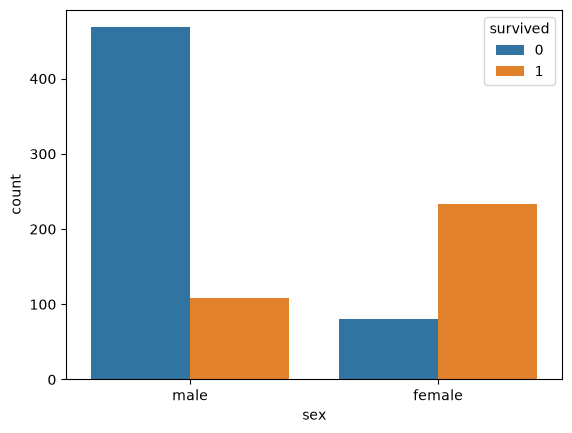

In [9]:
sns.countplot(data=df, x='sex', hue='survived')

In [10]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

<Axes: xlabel='pclass', ylabel='count'>

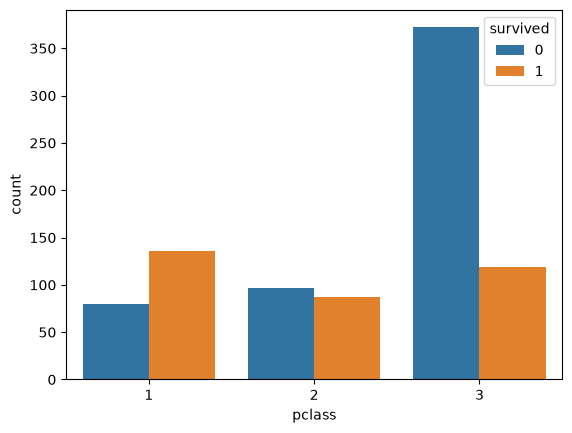

In [11]:
sns.countplot(data=df, x='pclass', hue='survived')

<Axes: xlabel='age', ylabel='Count'>

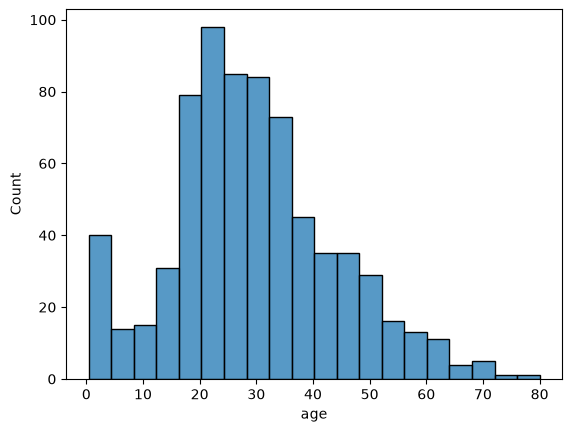

In [12]:
sns.histplot(data=df, x='age', bins=20)

<Axes: xlabel='fare'>

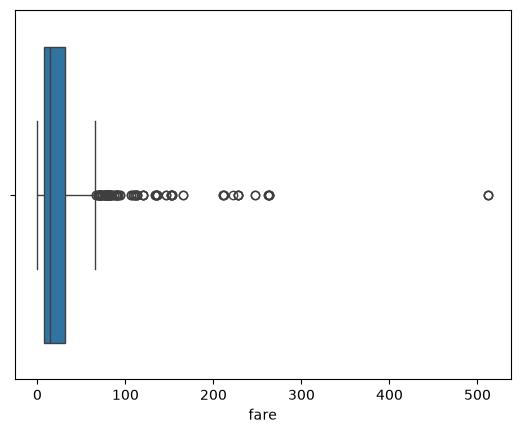

In [13]:
sns.boxplot(data=df, x='fare')

## EDA Conclusions

- Female passengers had a higher survival rate than male passengers.
- Passengers from the 1st class had a higher survival rate than passengers from the 2nd and 3rd classes.
- Most passengers were between approximately 20 and 40 years old.
- The fare distribution contains some very high values, which may be outliers.

## Data Preprocessing

Missing values in `age` were filled with the median age.

Missing values in `embarked` were filled using the most frequent value.

The `sex` and `embarked` categorical variables were converted into numerical features using one-hot encoding.

Columns that were not needed for the model were removed.

In [15]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [16]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [17]:
df['embarked'] = df['embarked'].fillna('S')

In [18]:
df = df.drop(columns=['deck', 'embark_town'])

In [19]:
df.isnull().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        0
class           0
who             0
adult_male      0
alive           0
alone           0
dtype: int64

In [20]:
df['age'].median()

np.float64(28.0)

In [21]:
df['age'] = df['age'].fillna(28)

In [22]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [23]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [24]:
df['embarked'].value_counts()

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [25]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], dtype=int)

In [26]:
df.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,alive,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,no,False,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,First,woman,False,yes,False,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,Third,woman,False,yes,True,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,First,woman,False,yes,False,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,Third,man,True,no,True,0,1,0,0,1


In [27]:
df.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'alive', 'alone', 'sex_female', 'sex_male', 'embarked_C',
       'embarked_Q', 'embarked_S'],
      dtype='str')

In [28]:
df = df.drop(columns=['class', 'who', 'adult_male', 'alive'])

In [29]:
df.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone',
       'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S'],
      dtype='str')

In [30]:
df.isnull().sum()

survived      0
pclass        0
age           0
sibsp         0
parch         0
fare          0
alone         0
sex_female    0
sex_male      0
embarked_C    0
embarked_Q    0
embarked_S    0
dtype: int64

In [31]:
df.dtypes

survived        int64
pclass          int64
age           float64
sibsp           int64
parch           int64
fare          float64
alone            bool
sex_female      int64
sex_male        int64
embarked_C      int64
embarked_Q      int64
embarked_S      int64
dtype: object

In [32]:
X = df.drop('survived', axis=1)

In [33]:
y = df['survived']

In [34]:
X.shape

(891, 11)

In [35]:
y.shape

(891,)

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
X_train.shape

(712, 11)

In [39]:
X_test.shape

(179, 11)

In [40]:
y_train.shape

(712,)

In [41]:
y_test.shape

(179,)

## Model Training

Two classification models were trained and compared:

1. Logistic Regression
2. Random Forest

The data was divided into training and testing sets. The test set was used to evaluate how well the models perform on unseen data.

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
model = LogisticRegression(max_iter=1000)

In [44]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [45]:
y_pred = model.predict(X_test)

In [46]:
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [48]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7988826815642458

In [49]:
precision = precision_score(y_test, y_pred)
precision

0.7714285714285715

In [50]:
recall = recall_score(y_test, y_pred)
recall

0.7297297297297297

In [51]:
f1 = f1_score(y_test, y_pred)
f1

0.75

In [52]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[89, 16],
       [20, 54]])

Evaluation of Logistic Regression

The Logistic Regression model achieved an accuracy of approximately 79.9%. The precision was 77.1%, recall was 73.0%, and F1-score was 75.0%.

The confusion matrix shows that the model correctly classified 89 passengers who did not survive and 54 passengers who survived. There were 16 false positive and 20 false negative predictions.

Accuracy alone is not enough to evaluate the model because it does not show the types of errors made by the classifier. Precision and recall provide additional information about the model's performance.

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [55]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [56]:
rf_pred = rf_model.predict(X_test)

In [57]:
rf_pred[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1])

In [58]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

accuracy_rf, precision_rf, recall_rf, f1_rf

NameError: name 'y_pred_rf' is not defined

In [59]:
y_pred_rf = rf_model.predict(X_test)

In [60]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

accuracy_rf, precision_rf, recall_rf, f1_rf

(0.8100558659217877,
 0.7857142857142857,
 0.7432432432432432,
 0.7638888888888888)

In [61]:
results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1": [f1, f1_rf]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.798883,0.771429,0.729730,0.750000
1,Random Forest,0.810056,0.785714,0.743243,0.763889


## Model Comparison

Random Forest performed slightly better than Logistic Regression on the test set.

Random Forest achieved an accuracy of approximately 81.0%, while Logistic Regression achieved approximately 79.9%.

Random Forest also had higher precision, recall, and F1-score. Therefore, Random Forest was selected as the better-performing model for this dataset.

## Results

Random Forest performed slightly better than Logistic Regression.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 79.9% | 77.1% | 73.0% | 75.0% |
| Random Forest | 81.0% | 78.6% | 74.3% | 76.4% |

### Conclusion

Random Forest achieved the best overall performance on the test set, with an accuracy of 81.0% and an F1-score of 76.4%.

The project demonstrates the basic machine learning workflow: data exploration, preprocessing, model training, evaluation and model comparison.